In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='LBA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 721/721 [01:35<00:00,  7.56it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.029893,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.106969,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.005561,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.047000,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.148092,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0040_L1IF2-3', 'D0040_L1IF3-4', 'D0079_LFAI1-2', 'D0079_LFAI2-3', 'D0079_LFMI1-2', 'D0079_LPI9-10', 'D0103_LAI7-8', 'D0103_LAI3-4', 'D0103_LAI5-6', 'D0103_LAI6-7']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 387776
PIC electrode count: 450432


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.029893,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.106969,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.005561,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.047000,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.148092,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


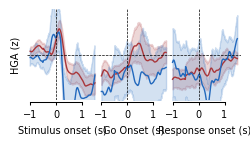

In [ ]:
rois = ['AIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.hemi=='L')
    & (HGAs.subject!='D0121')
    & (HGAs.roi.isin(rois) | HGAs.label.str.contains('Opercular'))
]

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(7*cm, 3*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
line1 = sns.lineplot(
    data=subset[(subset.phase == 'stimulus')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax1,
    palette=colors,
    legend=False,
    lw=1
)

line3 = sns.lineplot(
    data=subset[(subset.phase == 'go')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax2,
    palette=colors,
    legend=False,
    lw=1
)

line4 = sns.lineplot(
    data=subset[(subset.phase == 'response')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax3,
    palette=colors,
    legend=True,
    lw=1
)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == ax2 and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.2, 0.2)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Go Onset (s)', fontsize=7)   
ax3.set_xlabel('Response onset (s)', fontsize=7)   

ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
# plt.savefig('../img/fig2/fig2_AIPI_temporal_LS.svg', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# drop columns
cords = HGAs.copy().drop(columns=["time","value"]).drop_duplicates()
cords.head()

,channel,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,D0019_ROG1-2,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,D0019_ROG2-3,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,D0019_ROG4-5,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,D0019_ROG6-7,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,D0019_ROG7-8,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [8]:
pick = cords[(cords.roi=='AIC')| (cords.label.str.contains('Opercular')) & (cords.hemi=='L')]

# Find subjects that have both IFG and AIC
subjects_with_both = pick.groupby('subject')['roi'].apply(lambda x: set(x) >= {'IFG', 'AIC'})
subjects_with_both = subjects_with_both[subjects_with_both].index.tolist()

# Filter data for subjects with both ROIs
filtered_data = pick[pick.subject.isin(subjects_with_both)]

# Create MultiIndex DataFrame with each electrode as separate row
electrode_df = filtered_data.set_index(['subject', 'roi']).sort_index()

# Display the MultiIndex DataFrame
electrode_df

channel   mask description           task  phase modality  \
subject roi                                                                    
D0032   AIC   D0032_LAI1-2  False    Decision   LexicalDelay  delay    sound   
        AIC   D0032_LAI3-4  False    Decision   LexicalDelay  delay    sound   
        AIC   D0032_LAI4-5  False    Decision   LexicalDelay  delay    sound   
        AIC   D0032_LAI1-2  False      Repeat   LexicalDelay  delay    sound   
        AIC   D0032_LAI3-4  False      Repeat   LexicalDelay  delay    sound   
...                    ...    ...         ...            ...    ...      ...   
D0106   IFG  D0106_LTAS4-5   True     Passive  PictureNaming     go     text   
        IFG  D0106_LTAS4-5  False     Passive  PictureNaming     go     text   
        IFG  D0106_LTAS3-4  False      Repeat  PictureNaming     go     text   
        IFG  D0106_LTAS4-5  False      Repeat  PictureNaming     go     text   
        IFG  D0106_LTAS4-5   True      Repeat  PictureNaming     go     text   

                                    label hemi          x          y         z  
subject roi                                                                     
D0032   AIC        ctx_lh_G_insular_short    L -37.007849   9.260216 -8.201160  
        AIC        ctx_lh_G_insular_short    L -37.042906  10.072254 -0.909710  
        AIC  ctx_lh_S_circular_insula_sup    L -37.060344  10.755693  2.733611  
        AIC        ctx_lh_G_insular_short    L -37.007849   9.260216 -8.201160  
        AIC        ctx_lh_G_insular_short    L -37.042906  10.072254 -0.909710  
...                                   ...  ...        ...        ...       ...  
D0106   IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  
        IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  
        IFG  ctx_lh_G_front_inf-Opercular    L -47.882854   5.629037 -7.528778  
        IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  
        IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  

[554 rows x 11 columns]

In [9]:
filtered_data.subject.unique()

array(['D0035', 'D0040', 'D0067', 'D0094', 'D0096', 'D0032', 'D0106'],
      dtype=object)

In [143]:
# load raw data
LEXICAL_DELAY_PT = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'
PHONEME_PT = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'


sub = 'D0096'
# Get channels for AIC and IFG separately
aic_chns = electrode_df.loc[(sub, 'AIC'), 'channel'].unique().tolist()
ifg_chns = electrode_df.loc[(sub, 'IFG'), 'channel'].unique().tolist()

pick_chns = aic_chns + ifg_chns

raw_pt = BIDSPath(
    root=os.path.join(LEXICAL_DELAY_PT, 'derivatives', 'epoch(bipolar)'),
    datatype='epoch(raw)',
    subject=sub,
    # suffix='lowband',
    processing='baseline',
    extension='.h5',
    check=False
)
raw_pt = raw_pt.match()[0]
raw_epo = mne.read_epochs(raw_pt, preload=True, verbose='error')  # 改为 preload=True
raw_epo = raw_epo.pick_channels(pick_chns, verbose='error')
raw_epo = raw_epo.crop(tmin=None, tmax=0)
# raw_epo = raw_epo.average()

In [144]:
df = raw_epo.to_data_frame(long_format=True)
df['roi'] = ' '
df.loc[df.channel.isin(aic_chns), 'roi'] = 'AIC'
df.loc[df.channel.isin(ifg_chns), 'roi'] = 'IFG'
df.head()

Converting "condition" to "category"...
Converting "epoch" to "category"...
Converting "channel" to "category"...
Converting "ch_type" to "category"...


,condition,epoch,time,channel,ch_type,value,roi
0,Cue/Yes_No/Word/petal/EARLY_RESP,0,-1.0,D0096_LFAI2-3,seeg,0.083648,AIC
1,Cue/Yes_No/Word/petal/EARLY_RESP,0,-1.0,D0096_LFAI4-5,seeg,0.026787,AIC
2,Cue/Yes_No/Word/petal/EARLY_RESP,0,-1.0,D0096_LFAI5-6,seeg,0.035186,AIC
3,Cue/Yes_No/Word/petal/EARLY_RESP,0,-1.0,D0096_LIA1-2,seeg,-0.006496,AIC
4,Cue/Yes_No/Word/petal/EARLY_RESP,0,-1.0,D0096_LIA2-3,seeg,0.004071,AIC


In [145]:
# Compute AIC×IFG cross-correlation on raw (non-averaged) epochs
import numpy as np
from scipy.signal import correlate

# 1) Reload raw epochs WITHOUT averaging/cropping
raw_epo_full = mne.read_epochs(raw_pt, preload=True, verbose='error')
raw_epo_full = raw_epo_full.pick_channels(pick_chns, verbose='error')

# 2) Helper: z-scored cross-correlation (amplitude-invariant)
# Returns: xcorr shape (n_epochs, n_aic, n_ifg, n_lags), lag_times (seconds)
def compute_aic_ifg_xcorr_z(epochs, aic_chns, ifg_chns, max_lag_seconds=1.0):
    sfreq = epochs.info['sfreq']
    max_lag = int(round(max_lag_seconds * sfreq)) if max_lag_seconds is not None else None

    # data shapes: (n_epochs, n_chan, n_times)
    data_aic = epochs.get_data(picks=aic_chns)
    data_ifg = epochs.get_data(picks=ifg_chns)
    n_epo, n_aic, n_t = data_aic.shape
    _, n_ifg, _ = data_ifg.shape

    # z-score per epoch per channel (remove mean, divide by std)
    def zscore(x, axis=-1):
        m = x.mean(axis=axis, keepdims=True)
        s = x.std(axis=axis, keepdims=True)
        s[s == 0] = 1.0  # avoid division by zero
        return (x - m) / s

    data_aic_z = zscore(data_aic)
    data_ifg_z = zscore(data_ifg)

    # lag grid
    full_lags = np.arange(-n_t + 1, n_t)
    if max_lag is not None:
        keep = (full_lags >= -max_lag) & (full_lags <= max_lag)
    else:
        keep = slice(None)
    lags = full_lags[keep]
    lag_times = lags / sfreq

    # allocate
    xcorr = np.empty((n_epo, n_aic, n_ifg, lags.size), dtype=np.float64)

    # correlate z-scored signals; normalize by length to get Pearson-like scale
    norm = n_t  # optional: use np.sqrt(np.sum(x^2) * np.sum(y^2)) if you change padding
    for e in range(n_epo):
        for i in range(n_aic):
            for j in range(n_ifg):
                c = correlate(data_aic_z[e, i], data_ifg_z[e, j], mode='full', method='auto')
                xcorr[e, i, j] = c[keep] / norm
    return xcorr, lag_times

# Example: lag window ±1 s, z-scored (amplitude-invariant)
xcorr, lag_times = compute_aic_ifg_xcorr_z(raw_epo_full, aic_chns, ifg_chns, max_lag_seconds=1.0)
print('xcorr shape:', xcorr.shape)  # (n_epochs, n_aic, n_ifg, n_lags)
print('lag_times (s) range:', lag_times[0], 'to', lag_times[-1])

# square to convert to variance explained
xcorr = xcorr**2

# xcorr = xcorr.mean(axis=0)  # if you want AIC×IFG×lag averaged across epochs

xcorr shape: (170, 11, 1, 4097)
lag_times (s) range: -1.0 to 1.0


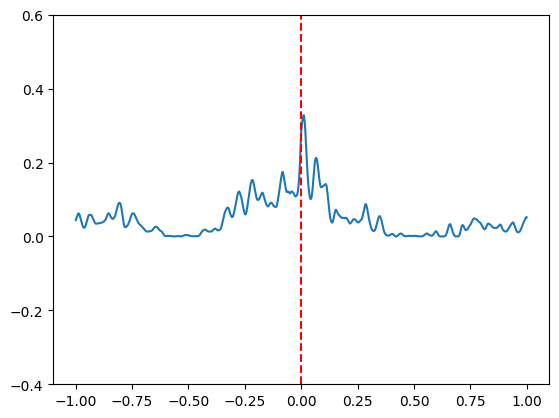

In [147]:
i = 1
j = 0
k = 20

fig, ax = plt.subplots()

a = xcorr[k,i,j,:]
sign = np.sign(a[np.argmax(np.abs(a))])
plt.plot(lag_times,a*sign)

vmin, vmax = np.percentile(xcorr, (1, 99))
ax.set_ylim(-0.4,0.6)

# ax.set_xlim(-0.3,0.3)

ax.axvline(x=0, color='r', linestyle='--')

<Axes: xlabel='time', ylabel='value'>

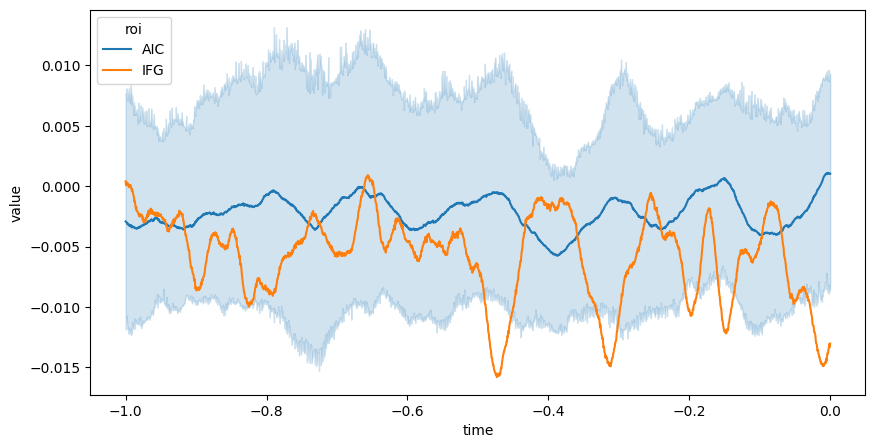

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(data=df, x='time', y='value', hue='roi', ax=ax)